 # 09_Model_Comparison

## Comparative Analysis of K-Means, Hierarchical Clustering, and DBSCAN

This notebook compares three clustering algorithms applied to the Online Retail RFM dataset and identifies the most suitable model for customer segmentation.

## Objective

The objective of this notebook is to compare K-Means, Hierarchical Clustering (Ward Linkage), and DBSCAN using the same RFM dataset.

The comparison focuses on:

- Clustering quality
- Silhouette Score
- Cluster distribution
- Outlier detection
- Business interpretation
- Model scalability
- Production suitability

The goal is to determine which algorithm is the most appropriate for customer segmentation.

In [2]:
import pandas as pd

In [3]:
comparison = pd.DataFrame({

    "Algorithm":["K-Means","Hierarchical (Ward)","DBSCAN"],
    "Learning Type":["Centroid-Based","Distance-Based","Density-Based"],
    "Silhouette Score":[0.5097,0.5774,0.6874],
    "Clusters":[3,3,2],
    "Noise Points":[0,0,49],
    "Scalable":["High","Medium","Medium"]
})

comparison

,Algorithm,Learning Type,Silhouette Score,Clusters,Noise Points,Scalable
0,K-Means,Centroid-Based,0.5097,3,0,High
1,Hierarchical (Ward),Distance-Based,0.5774,3,0,Medium
2,DBSCAN,Density-Based,0.6874,2,49,Medium


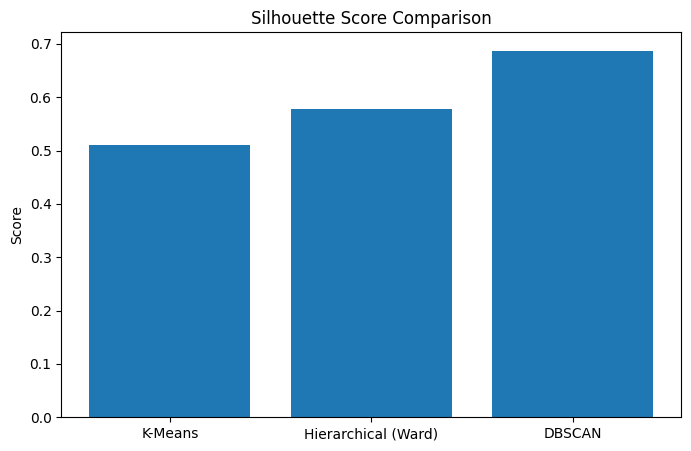

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Algorithm"],
    comparison["Silhouette Score"])

plt.title("Silhouette Score Comparison")
plt.ylabel("Score")
plt.show()

## Cluster Distribution

### K-Means

- Cluster 0 → 1082 Customers
- Cluster 1 → 3230 Customers
- Cluster 2 → 26 Customers

### Hierarchical Clustering (Ward)

- Cluster 0 → 3189 Customers
- Cluster 1 → 15 Customers
- Cluster 2 → 1134 Customers

### DBSCAN

- Cluster 0 → 4284 Customers
- Cluster 1 → 5 Customers
- Noise → 49 Customers

Observation:

K-Means and Ward produced meaningful customer groups.

DBSCAN identified outliers successfully but produced only two customer clusters, making it less suitable for customer segmentation on this dataset.

# Business Interpretation

## K-Means

Advantages

- Fast
- Easy to deploy
- Highly scalable
- Well suited for large datasets

Limitations

- Requires choosing K beforehand.
- Assumes relatively compact clusters.

---

## Hierarchical Clustering (Ward)

Advantages

- Produced the best balanced customer segments.
- Achieved a higher Silhouette Score than K-Means.
- Provides a Dendrogram for visual analysis.

Limitations

- Computationally expensive on large datasets.
- Less scalable than K-Means.

---

## DBSCAN

Advantages

- Detects outliers automatically.
- No need to specify the number of clusters in advance.

Limitations

- Highly sensitive to eps and min_samples.
- Produced only two customer clusters on this dataset.
- Cluster quality depends heavily on parameter tuning.

In [5]:
feature_table = pd.DataFrame({

"Feature":[
"Need K",
"Handles Outliers",
"Dendrogram",
"Scalable",
"Best for Large Data",
"Business Interpretation"
],

"K-Means":[
"Yes",
"No",
"No",
"High",
"Yes",
"Easy"
],

"Hierarchical":[
"No",
"No",
"Yes",
"Medium",
"No",
"Very Good"
],

"DBSCAN":[
"No",
"Yes",
"No",
"Medium",
"Medium",
"Moderate"
]

})

feature_table

,Feature,K-Means,Hierarchical,DBSCAN
0,Need K,Yes,No,No
1,Handles Outliers,No,No,Yes
2,Dendrogram,No,Yes,No
3,Scalable,High,Medium,Medium
4,Best for Large Data,Yes,No,Medium
5,Business Interpretation,Easy,Very Good,Moderate


# Final Recommendation

Although DBSCAN achieved the highest Silhouette Score (0.6874), it produced only two customer clusters and classified 49 customers as noise. While this behavior is useful for anomaly detection, it is less appropriate for business-oriented customer segmentation where multiple meaningful customer groups are required.

Hierarchical Clustering (Ward Linkage) produced a higher Silhouette Score (0.5774) than K-Means and generated balanced, interpretable customer segments. However, its computational complexity makes it less suitable for very large datasets.

K-Means achieved a slightly lower Silhouette Score (0.5097) but offered the best balance between performance, scalability, simplicity, and deployment readiness. It generated three practical customer segments that align well with common business use cases such as VIP, Regular, and At-Risk customers.

Therefore:

- **Primary Model (Dashboard): K-Means**
- **Best Hierarchical Method: Ward Linkage**
- **Best for Outlier Detection: DBSCAN**

In [6]:
summary = pd.DataFrame({

"Algorithm":[
"K-Means",
"Hierarchical (Ward)",
"DBSCAN"
],

"Best Use Case":[
"Customer Segmentation",
"Customer Segmentation",
"Outlier Detection"
],

"Overall Performance":[
"Excellent",
"Very Good",
"Good"
],

"Recommended":[
"✅ Yes",
"✅ Comparison",
"✅ Outlier Detection"
]

})

summary

,Algorithm,Best Use Case,Overall Performance,Recommended
0,K-Means,Customer Segmentation,Excellent,✅ Yes
1,Hierarchical (Ward),Customer Segmentation,Very Good,✅ Comparison
2,DBSCAN,Outlier Detection,Good,✅ Outlier Detection


# Conclusion

Three clustering algorithms were evaluated using the same RFM customer dataset.

- **K-Means** delivered a scalable and business-friendly solution suitable for deployment.
- **Hierarchical Clustering (Ward)** achieved stronger cluster separation and provided valuable insights through the dendrogram.
- **DBSCAN** effectively detected outliers but was less suitable for creating multiple business-focused customer segments.

This comparative analysis demonstrates that selecting a clustering algorithm should not rely solely on evaluation metrics. Business interpretability, scalability, and the specific problem context are equally important when choosing a production-ready solution.

# Key Learnings

- Compared three clustering algorithms on the same dataset.
- Learned that a higher Silhouette Score does not always indicate a better business solution.
- Understood the strengths and limitations of K-Means, Hierarchical Clustering, and DBSCAN.
- Evaluated algorithms based on metrics, cluster quality, scalability, and business applicability.
- Selected the most appropriate model for deployment using both technical and business criteria.